In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,roc_auc_score,roc_curve,confusion_matrix,precision_recall_curve,f1_score)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
train_df=pd.read_csv('train_preprocessed.csv')
val_df=pd.read_csv('val_preprocessed.csv')
test_df=pd.read_csv('test_preprocessed.csv')
print(f"Train:{train_df.shape},Val:{val_df.shape},Test:{test_df.shape}")

Train:(3500, 26),Val:(750, 26),Test:(750, 26)


In [32]:
leak_features = ['placement_country','placement_status','placed_flag','placement_company','destination_country','destination_city',"student_id"]

In [33]:
train_df.drop(columns=leak_features,errors="ignore",inplace=True)
val_df.drop(columns=leak_features,errors="ignore",inplace=True)
test_df.drop(columns=leak_features,errors="ignore",inplace=True)

In [34]:
target_col="stay_in_canada"
X_train,y_train=train_df.drop(columns=[target_col]),train_df[target_col]
X_val,y_val=val_df.drop(columns=[target_col]),val_df[target_col]
X_test,y_test=test_df.drop(columns=[target_col]),test_df[target_col]

In [35]:
print("\n Applying SMOTE to balance training data")
print(f"Before SMOTE:Positive ratio={y_train.mean():.4f}")


 Applying SMOTE to balance training data
Before SMOTE:Positive ratio=0.0506


In [36]:
for col in X_train.select_dtypes(exclude=[np.number]).columns:
    print(f"Encoding column:{col}")
    le=LabelEncoder()
    le.fit(pd.concat([X_train[col],X_val[col],X_test[col]],axis=0).astype(str))
    X_train[col]=le.transform(X_train[col].astype(str))
    X_val[col]=le.transform(X_val[col].astype(str))
    X_test[col]=le.transform(X_test[col].astype(str))

Encoding column:scholarship_received


In [37]:
smote=SMOTE(random_state=42)
X_train_bal,y_train_bal=smote.fit_resample(X_train,y_train)
print(f"After SMOTE:Positive ratio={y_train_bal.mean():.4f}")
print(f"Balanced training set size:{X_train_bal.shape}")

After SMOTE:Positive ratio=0.5000
Balanced training set size:(6646, 18)


In [38]:
model=RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1,class_weight="balanced_subsample")
model.fit(X_train_bal,y_train_bal)
print("\n Model trained successfully.")


 Model trained successfully.


In [39]:
y_val_prob=model.predict_proba(X_val)[:,1]
roc_auc=roc_auc_score(y_val,y_val_prob)
fpr,tpr,roc_thresholds=roc_curve(y_val,y_val_prob)
prec,rec,pr_thresholds=precision_recall_curve(y_val,y_val_prob)

In [40]:
def optimal_thresholds(y_true,y_prob):
    fpr,tpr,thr_roc=roc_curve(y_true,y_prob)
    j_scores=tpr-fpr
    youden_t=thr_roc[np.argmax(j_scores)]
    prec,rec,thr_pr=precision_recall_curve(y_true,y_prob)
    f1s=[2*(p*r)/(p+r) if (p+r)>0 else 0 for p,r in zip(prec,rec)]
    f1_best_t=thr_pr[np.argmax(f1s)]
    recall_focus_t=0.15
    precision_focus_t=0.40
    return {"youden_optimal":round(youden_t,3),"f1_optimal":round(f1_best_t,3),"recall_focus":recall_focus_t,"precision_focus":precision_focus_t}
thresholds=optimal_thresholds(y_val,y_val_prob)
print(f"\n Threshold candidates based on validation data:")
for name,val in thresholds.items():
    print(f"{name:20s}→{val}")


 Threshold candidates based on validation data:
youden_optimal      →0.11
f1_optimal          →0.403
recall_focus        →0.15
precision_focus     →0.4


In [41]:
final_threshold=thresholds["f1_optimal"]
print(f"\n Final decision threshold={final_threshold:.3f}")


 Final decision threshold=0.403


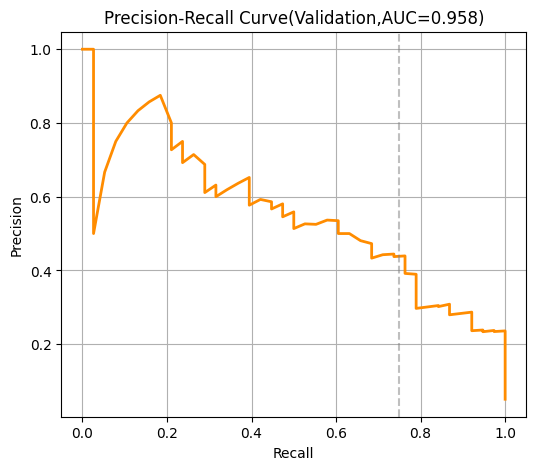

In [42]:
plt.figure(figsize=(6,5))
plt.plot(rec,prec,color='darkorange',lw=2)
plt.axvline(0.75,color='gray',linestyle='--',alpha=0.5)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve(Validation,AUC={roc_auc:.3f})")
plt.grid(True)
plt.show()

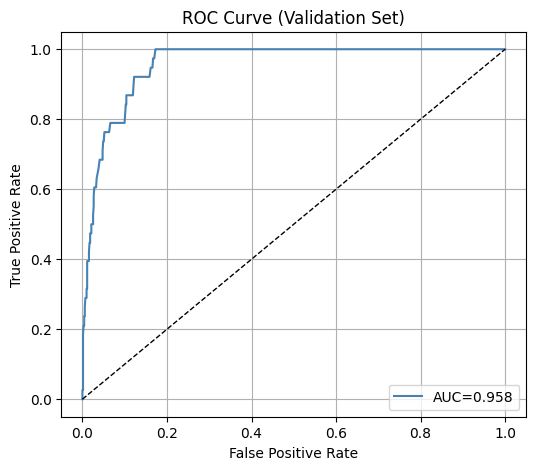

In [43]:
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}",color="steelblue")
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
def evaluate_with_threshold(threshold,y_true,y_prob,label):
    y_pred=(y_prob>=threshold).astype(int)
    print(f"\n [{label}] Threshold={threshold}")
    print(classification_report(y_true,y_pred,digits=4))
    auc=roc_auc_score(y_true,y_prob)
    print(f"ROC-AUC Score:{auc:.4f}")
    cm=confusion_matrix(y_true,y_pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
                xticklabels=['No Stay','Stay'],yticklabels=['No Stay','Stay'])
    plt.title(f'Confusion Matrix({label})')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    TN,FP,FN,TP=cm.ravel()
    fprate=FP/(FP+TN)
    print(f"False Positive Rate:{fprate*100:.2f}%")
    print("-"*60)
y_test_prob=model.predict_proba(X_test)[:,1]


 [Scenario A–High Recall(T=0.15)] Threshold=0.15
              precision    recall  f1-score   support

           0     0.9917    0.8413    0.9103       712
           1     0.2260    0.8684    0.3587        38

    accuracy                         0.8427       750
   macro avg     0.6089    0.8549    0.6345       750
weighted avg     0.9529    0.8427    0.8824       750

ROC-AUC Score:0.9350


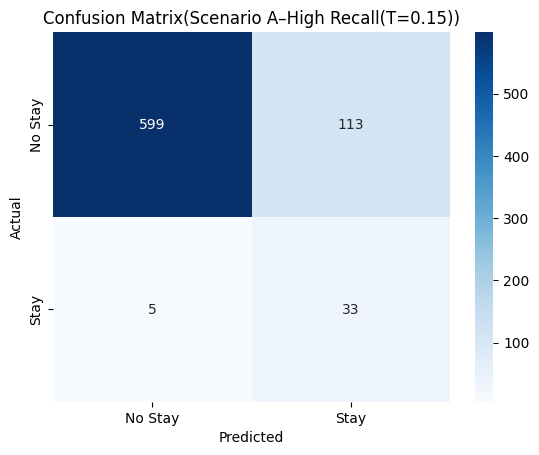

False Positive Rate:15.87%
------------------------------------------------------------

 [Scenario B–Balanced(F1 Best)] Threshold=0.403
              precision    recall  f1-score   support

           0     0.9717    0.9649    0.9683       712
           1     0.4186    0.4737    0.4444        38

    accuracy                         0.9400       750
   macro avg     0.6952    0.7193    0.7064       750
weighted avg     0.9437    0.9400    0.9417       750

ROC-AUC Score:0.9350


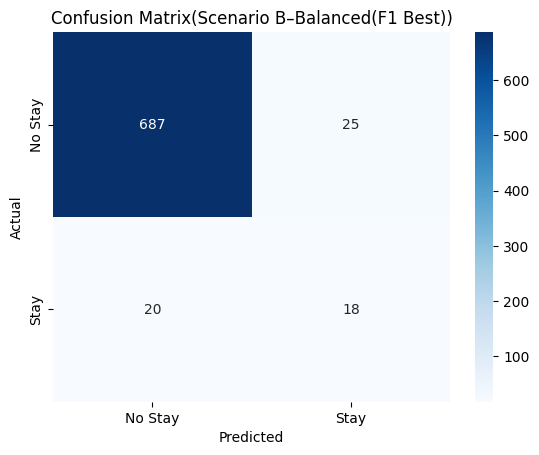

False Positive Rate:3.51%
------------------------------------------------------------

 [Scenario C–High Precision (T=0.40)] Threshold=0.4
              precision    recall  f1-score   support

           0     0.9731    0.9649    0.9690       712
           1     0.4318    0.5000    0.4634        38

    accuracy                         0.9413       750
   macro avg     0.7025    0.7324    0.7162       750
weighted avg     0.9457    0.9413    0.9434       750

ROC-AUC Score:0.9350


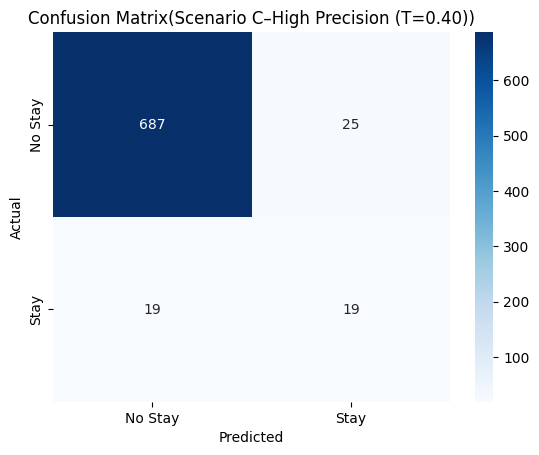

False Positive Rate:3.51%
------------------------------------------------------------


In [45]:
evaluate_with_threshold(thresholds["recall_focus"],y_test,y_test_prob,"Scenario A–High Recall(T=0.15)")
evaluate_with_threshold(thresholds["f1_optimal"],y_test,y_test_prob,"Scenario B–Balanced(F1 Best)")
evaluate_with_threshold(thresholds["precision_focus"],y_test,y_test_prob,"Scenario C–High Precision (T=0.40)")

/tmp/ipython-input-2886110344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance.head(10),x="importance",y="feature",palette="viridis")


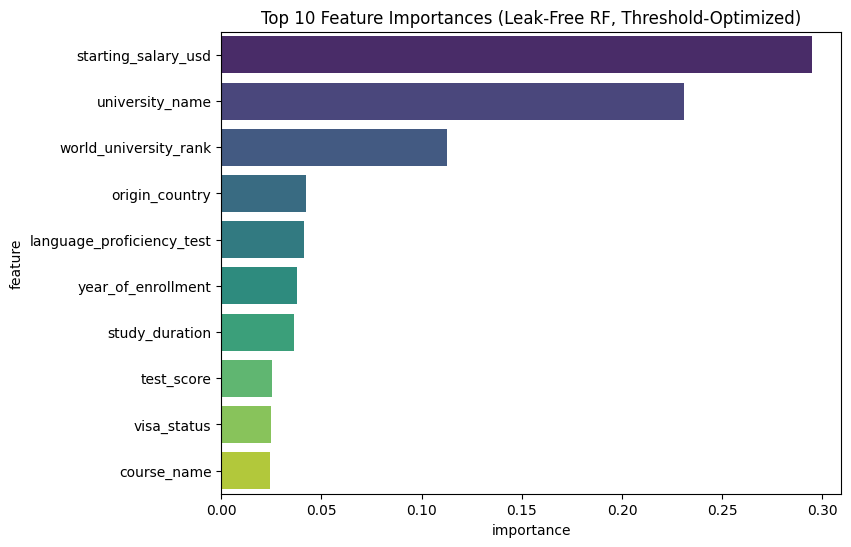


 Full training,tuning and evaluation complete.


In [46]:
feat_importance = pd.DataFrame({"feature":X_train.columns,"importance":model.feature_importances_}).sort_values("importance",ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(data=feat_importance.head(10),x="importance",y="feature",palette="viridis")
plt.title("Top 10 Feature Importances (Leak-Free RF, Threshold-Optimized)")
plt.show()
print("\n Full training,tuning and evaluation complete.")